<a href="https://colab.research.google.com/github/smartanilmali234-art/Anilmali/blob/main/Week_5_Task_1_Imbalanced_Data_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 – Handling Imbalanced & Messy Real-World Data

## Credit Card Fraud Detection

**Machine Learning Fundamentals – Week 5**

### Objective
- Understand class imbalance
- Analyze fraud vs. normal transactions
- Apply SMOTE to balance the training data
- Train a machine learning model before and after balancing
- Compare Accuracy, Precision, Recall, and F1-score
- Understand why accuracy can be misleading for imbalanced datasets

## Problem Statement

Credit card fraud detection is a real-world classification problem where fraudulent
transactions are much rarer than legitimate transactions.

Because of this imbalance, a model can achieve very high accuracy while still failing
to detect many fraudulent transactions.

In this assignment, we will use SMOTE to address class imbalance and compare model
performance before and after balancing.

In [22]:
# Install imbalanced-learn
!pip install -q imbalanced-learn

## Import Required Libraries

We will use pandas and NumPy for data processing, Matplotlib and Seaborn for
visualization, scikit-learn for machine learning and evaluation, and SMOTE from
imbalanced-learn for handling class imbalance.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

The Credit Card Fraud Detection dataset contains transactions where:

- `Class = 0` → Normal transaction
- `Class = 1` → Fraudulent transaction

The dataset file is expected to be named `creditcard.csv`.

In [24]:
# Load dataset
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (11959, 31)


## Explore the Dataset

Let's inspect the first few rows to understand the structure of the dataset.

In [25]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


## Dataset Information

We will check:

- Number of rows and columns
- Data types
- Missing values
- General dataset structure

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11959 entries, 0 to 11958
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    11959 non-null  int64  
 1   V1      11959 non-null  float64
 2   V2      11959 non-null  float64
 3   V3      11959 non-null  float64
 4   V4      11959 non-null  float64
 5   V5      11959 non-null  float64
 6   V6      11959 non-null  float64
 7   V7      11959 non-null  float64
 8   V8      11959 non-null  float64
 9   V9      11959 non-null  float64
 10  V10     11959 non-null  float64
 11  V11     11959 non-null  float64
 12  V12     11959 non-null  float64
 13  V13     11959 non-null  float64
 14  V14     11959 non-null  float64
 15  V15     11959 non-null  float64
 16  V16     11959 non-null  float64
 17  V17     11959 non-null  float64
 18  V18     11959 non-null  float64
 19  V19     11959 non-null  float64
 20  V20     11958 non-null  float64
 21  V21     11958 non-null  float64
 22

## Check for Missing Values

Before training a machine learning model, it is important to check whether the
dataset contains missing values.

In [27]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found.")

Missing values in each column:
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


## Check Class Distribution

The target variable is `Class`.

- 0 represents legitimate transactions.
- 1 represents fraudulent transactions.

We will calculate the number and percentage of each class.

In [28]:
class_counts = df["Class"].value_counts()

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print((class_counts / len(df) * 100).round(4))

Class Counts:
Class
0.0    11906
1.0       52
Name: count, dtype: int64

Class Percentages:
Class
0.0    99.5568
1.0     0.4348
Name: count, dtype: float64


## Visualize Class Imbalance

The following bar chart shows the difference between normal and fraudulent
transactions.

We expect the fraud class to be much smaller than the normal class.

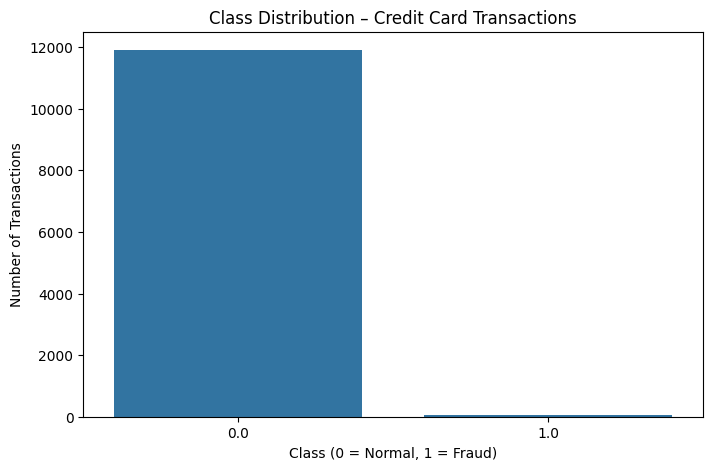

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution – Credit Card Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

## Prepare Features and Target

The `Class` column is our target variable.

All other columns will be used as input features.

In [30]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11959, 30)
Target shape: (11959,)


## Handle Missing Values

Real-world datasets can contain missing or invalid values.

Before splitting the data, we will check the target variable (`Class`) for
missing values. Machine learning models cannot train when the target contains
NaN values.

If missing target values are found, those rows will be removed because we
cannot determine whether those transactions are normal or fraudulent.

In [31]:
# Check missing values in the target column
print("Missing values in Class:", df["Class"].isnull().sum())

# Remove rows where the target variable is missing
df = df.dropna(subset=["Class"]).copy()

print("Dataset shape after removing missing Class values:", df.shape)

# Prepare features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values in target after cleaning:", y.isnull().sum())

Missing values in Class: 1
Dataset shape after removing missing Class values: (11958, 31)

Features shape: (11958, 30)
Target shape: (11958,)

Missing values in target after cleaning: 0


## Check Missing Values in Features

Next, we check whether the input features contain missing values.

If numerical feature values are missing, we will replace them using the median
of each feature. Using the median is a simple and robust approach for handling
missing numerical values.

In [32]:
# Check missing values in features
missing_features = X.isnull().sum()

print("Total missing values in features:", missing_features.sum())

if missing_features.sum() > 0:
    print("\nColumns containing missing values:")
    print(missing_features[missing_features > 0])
else:
    print("No missing values found in features.")

Total missing values in features: 0
No missing values found in features.


In [33]:
# Fill missing numerical feature values with the median
X = X.fillna(X.median(numeric_only=True))

print("Total missing values after cleaning:", X.isnull().sum().sum())

Total missing values after cleaning: 0


## Split the Dataset

We will split the cleaned dataset into:

- 80% training data
- 20% testing data

The `stratify=y` parameter maintains the original proportion of normal and
fraudulent transactions in both datasets.

The test data will remain untouched because it should represent realistic
unseen data.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data: (9566, 30)
Testing data: (2392, 30)

Training class distribution:
Class
0.0    9524
1.0      42
Name: count, dtype: int64

Testing class distribution:
Class
0.0    2382
1.0      10
Name: count, dtype: int64


## Baseline Model – Before SMOTE

First, we train Logistic Regression using the original imbalanced training data.

This gives us a baseline that we can compare against after applying SMOTE.

In [35]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print("Baseline model trained successfully.")

Baseline model trained successfully.


## Evaluate the Baseline Model

We will use:

- Accuracy
- Precision
- Recall
- F1-score

These metrics are more informative than accuracy alone when dealing with
imbalanced classification.

In [36]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)

print("Baseline Model Performance")
print("-" * 35)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

Baseline Model Performance
-----------------------------------
Accuracy : 0.9987
Precision: 0.8889
Recall   : 0.8000
F1 Score : 0.8421


## Apply SMOTE

SMOTE stands for **Synthetic Minority Over-sampling Technique**.

It creates synthetic examples of the minority class to make the training data
more balanced.

Important:
SMOTE is applied only to the training data. The test data is kept unchanged
so that evaluation represents realistic unseen data.

In [37]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution AFTER SMOTE:")
print(y_train_smote.value_counts())

Class distribution BEFORE SMOTE:
Class
0.0    9524
1.0      42
Name: count, dtype: int64

Class distribution AFTER SMOTE:
Class
0.0    9524
1.0    9524
Name: count, dtype: int64


## Train the Model After SMOTE

Now we train another Logistic Regression model using the balanced training data.

In [38]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)

print("SMOTE model trained successfully.")

SMOTE model trained successfully.


## Compare Model Performance

We compare the baseline model with the SMOTE model using:

- Accuracy
- Precision
- Recall
- F1-score

The goal is not simply to maximize accuracy. For fraud detection, identifying
fraudulent transactions correctly is especially important.

In [39]:
smote_accuracy = accuracy_score(y_test, y_pred_smote)
smote_precision = precision_score(y_test, y_pred_smote, zero_division=0)
smote_recall = recall_score(y_test, y_pred_smote, zero_division=0)
smote_f1 = f1_score(y_test, y_pred_smote, zero_division=0)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Before SMOTE": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "After SMOTE": [
        smote_accuracy,
        smote_precision,
        smote_recall,
        smote_f1
    ]
})

results

,Metric,Before SMOTE,After SMOTE
0,Accuracy,0.998746,0.996237
1,Precision,0.888889,0.529412
2,Recall,0.800000,0.900000
3,F1 Score,0.842105,0.666667


# Final Analysis and Conclusion

## Why Accuracy Is Misleading

Accuracy can be misleading for a highly imbalanced dataset such as credit card
fraud detection.

Fraudulent transactions represent only a very small percentage of all
transactions. A model could predict almost every transaction as normal and still
achieve extremely high accuracy.

However, such a model would fail to detect many fraudulent transactions.

For this reason, we should also focus on **Precision, Recall, and F1-score**.

### Precision

Precision tells us how many transactions predicted as fraud were actually fraud.

### Recall

Recall tells us how many of the actual fraudulent transactions were successfully
detected by the model.

For fraud detection, recall is particularly important because missing a real
fraudulent transaction can have serious consequences.

### F1-score

F1-score combines Precision and Recall into a single metric and is useful when
the classes are imbalanced.

## SMOTE

SMOTE was used to balance the training data by generating synthetic examples of
the minority fraud class.

The test dataset was not modified because it should represent the real-world
distribution of transactions.

## Conclusion

This assignment demonstrated the importance of handling imbalanced data in
real-world machine learning problems.

The baseline Logistic Regression model was first trained using the original
imbalanced data. SMOTE was then applied to the training data, and the model was
retrained.

The two approaches were compared using Accuracy, Precision, Recall, and F1-score.

The main lesson is that **high accuracy does not necessarily mean that an
imbalanced classification model is useful**. For fraud detection, Precision,
Recall, and F1-score provide a more meaningful evaluation of model performance.

## Key Learning

- Real-world datasets can be highly imbalanced.
- Accuracy alone can hide poor minority-class performance.
- SMOTE can help address class imbalance.
- SMOTE should be applied only to the training data.
- Precision, Recall, and F1-score are important metrics for fraud detection.

**Assignment Status: Week 5 – Completed**